# PoC V1 — Categorização automática de documentos/etiquetas/tags

**Objetivo:** treinar, avaliar e disponibilizar um modelo capaz de atribuir automaticamente uma das tags **AIAA, ESA, FAA ou NASA** a documentos PDF.

### Fluxo da PoC

1. Instalação e importação das bibliotecas.

2. Importação e extração do ZIP contendo os documentos organizados por pasta/tag.

3. Criação automática do dataset.

4. Extração, validação e limpeza dos textos.

5. Análise dos marcadores presentes nos documentos.

6. Separação estratificada de **80% para treinamento e 20% para teste**.

7. Vetorização dos textos utilizando **TF-IDF**.

8. Treinamento do classificador **LinearSVC**.

9. Avaliação do modelo por meio da matriz de confusão, acurácia, precisão, recall e F1.

10. Análise das previsões e dos termos mais relevantes para cada classe.

11. Classificação de novos documentos PDF.

12. Exportação do TF-IDF e do modelo treinado em um arquivo `.joblib` para posterior utilização no backend.

> **Importante:** atualmente a PoC suporta tanto **PDFs com camada de texto** quanto **PDFs escaneados**.
>
> O processamento é realizado de forma híbrida:
>
> - primeiro, o documento é validado como PDF;
> - em seguida, cada página é analisada com o **PyMuPDF**;
> - caso o PyMuPDF consiga extrair uma quantidade mínima de texto útil, esse conteúdo é utilizado normalmente;
> - caso a página possua pouco ou nenhum texto extraível, ela é tratada como página escaneada e processada com **OCR utilizando Tesseract**;
> - o texto obtido, independentemente da origem, passa posteriormente pela mesma etapa de limpeza, vetorização com TF-IDF e classificação com LinearSVC.
>
> Dessa forma, o fluxo de leitura funciona da seguinte maneira:
>
> ```text
> PDF
>  ↓
> Validação do arquivo
>  ↓
> PyMuPDF consegue extrair texto útil?
>  ├── Sim → utiliza o texto extraído
>  └── Não → aplica OCR com Tesseract
>                ↓
>           texto recuperado
>  ↓
> Limpeza e padronização
>  ↓
> TF-IDF
>  ↓
> LinearSVC
>  ↓
> Tag prevista
> ```
>
> Para melhorar o desempenho, o OCR é utilizado somente quando necessário, evitando o processamento de imagens em páginas que já possuem texto extraível.

## Sumário

1. **Instalação e importação das bibliotecas**  
   Instalação das dependências necessárias e importação das bibliotecas utilizadas para leitura dos PDFs, manipulação dos arquivos, tratamento dos dados, treinamento, avaliação e exportação do modelo.

2. **Importação dos arquivos, upload e extração**  
   Localização, validação e extração do arquivo ZIP no ambiente do Google Colab.

3. **Montagem do dataset**  
   Leitura dos documentos e criação automática do DataFrame com arquivo, caminho e tag.

4. **Validação inicial do dataset**  
   Verificação dos tipos de dados, valores nulos, quantidade de registros e distribuição das tags.

5. **Extração do texto dos documentos**  
   Extração do conteúdo textual dos PDFs utilizando PyMuPDF, limitada às primeiras 30 páginas.

6. **Processamento e armazenamento dos textos extraídos**  
   Processamento dos documentos e armazenamento dos textos e seus respectivos tamanhos no DataFrame.

7. **Limpeza e padronização dos textos**  
   Conversão para minúsculas e remoção de caracteres especiais, quebras de linha, tabulações e espaços duplicados.

8. **Validação dos textos processados**  
   Exibição de exemplos de textos tratados para verificar se a extração e a limpeza foram realizadas corretamente.

9. **Análise de marcadores das organizações**  
   Definição de termos relacionados às organizações para auxiliar na análise das características do dataset.

10. **Verificação da presença dos marcadores**  
    Análise da ocorrência dos marcadores nos documentos de cada categoria.

11. **Separação dos dados entre treinamento e teste**  
    Definição de `X` e `y` e divisão estratificada dos documentos em conjuntos de treinamento e teste.

12. **Vetorização dos textos com TF-IDF**  
    Transformação dos textos em representações numéricas utilizando `TfidfVectorizer`.

13. **Treinamento do modelo com LinearSVC**  
    Treinamento do classificador utilizando os vetores TF-IDF e as respectivas tags.

14. **Avaliação do modelo**  
    Avaliação utilizando matriz de confusão, acurácia, precisão, recall e F1.

15. **Análise detalhada das previsões**  
    Comparação individual entre a tag real e a tag prevista para cada documento do conjunto de teste.

16. **Análise dos termos mais importantes por classe**  
    Identificação dos termos que tiveram maior influência nas decisões do modelo.

17. **Modelo treinado e possibilidade de expansão**  
    Explicação sobre o modelo final e sobre como novas categorias podem ser adicionadas futuramente.

18. **Função para classificação de novos documentos**  
    Implementação da função responsável por processar um novo PDF e retornar sua tag prevista.

19. **Teste de classificação com novo documento**  
    Teste prático da PoC utilizando um documento externo ao conjunto utilizado no treinamento.

20. **Exportação do modelo treinado**  
    Persistência do `TfidfVectorizer` e do `LinearSVC` em um arquivo `.joblib`.

21. **Download do modelo treinado**  
    Download do arquivo gerado para posterior integração com o backend Python/Django REST.

22. **Resultado final da PoC**  
    Resumo do fluxo desenvolvido, resultados obtidos, utilização do modelo, integração com o backend e possibilidade de inclusão de novas tags.

## **Importante**: Sobre a escolha do algoritmo de classificação:
O LinearSVC foi escolhido porque nossa entrada é composta por textos transformados em números pelo TF-IDF. Essa transformação gera muitas características, correspondentes às palavras e combinações de palavras dos documentos, sendo que várias delas possuem valor zero em cada arquivo. O LinearSVC trabalha muito bem com esse tipo de representação e é mais simples para o tamanho atual do nosso dataset. Diferentemente dos testes realizados com o MLPClassifier, não utilizamos o StandardScaler, pois o TF-IDF já transforma e normaliza os textos em uma representação numérica adequada para o nosso modelo.

## 1. Instalação e importação das bibliotecas
Instalação das dependências necessárias e importação das bibliotecas.

In [236]:
# Instala as bibliotecas necessárias para leitura dos PDFs,
# tratamento dos dados, treinamento do modelo,
# avaliação dos resultados e salvamento do modelo.

# Atualiza a lista de pacotes do ambiente Linux
!apt-get update -qq

# Instala o Tesseract OCR
# tesseract-ocr     -> motor responsável por reconhecer texto em imagens
# tesseract-ocr-eng -> pacote de reconhecimento para textos em inglês
!apt-get install -y tesseract-ocr tesseract-ocr-eng > /dev/null

# Instala as bibliotecas Python utilizadas na PoC
#
# pymupdf       -> leitura de PDFs e extração de texto
# pytesseract   -> integração do Python com o Tesseract OCR
# pillow        -> manipulação das imagens geradas a partir das páginas do PDF
# scikit-learn  -> TF-IDF, LinearSVC, divisão dos dados e métricas
# pandas        -> organização e análise dos dados em DataFrame
# matplotlib    -> exibição da matriz de confusão e gráficos
# joblib        -> salvamento e carregamento do modelo treinado
!pip install pymupdf pytesseract pillow scikit-learn pandas matplotlib joblib -q

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [237]:
import io
import pytesseract

from PIL import Image

# Importa biblioteca para tratamento de texto com expressões regulares
import re

# Importa biblioteca para manipulação de arquivos ZIP
import zipfile

# Importa biblioteca para operações com arquivos e pastas
import shutil

# Importa Path para trabalhar com caminhos de arquivos de forma mais simples
from pathlib import Path

# Importa PyMuPDF para leitura e extração de texto dos PDFs
import pymupdf

# Importa Pandas para organização e análise dos dados em DataFrame
import pandas as pd

# Importa Matplotlib para exibição de gráficos
import matplotlib.pyplot as plt

## 1. Importação dos arquivos

Nesta etapa, o arquivo ZIP contendo os documentos é localizado no armazenamento do Colab, validado e extraído para a pasta que será utilizada no processamento.


O ZIP deve conter os PDFs separados em pastas cujo nome representa a tag.

Exemplo:

# **IMPORTANTE**

```text
DOCS_API/
├── tecnico - AIAA/
├── qualitativo - ESA/
├── juridico - FAA/
└── normativo - NASA/
```

In [238]:
# Define o caminho do arquivo ZIP enviado para o armazenamento do Colab
zip_path = Path("/content/DOCS_API.zip")

# Verifica se o arquivo ZIP existe antes de continuar
if not zip_path.exists():
    raise FileNotFoundError(
        "Arquivo DOCS_API.zip não encontrado em /content."
    )

# Define a pasta onde os documentos serão extraídos
pasta_destino = Path("/content/dataset_tags")

# Remove a pasta de uma execução anterior, caso ela já exista
if pasta_destino.exists():
    shutil.rmtree(pasta_destino)

# Cria novamente a pasta onde os arquivos serão extraídos
pasta_destino.mkdir(
    parents=True,
    exist_ok=True
)

# Abre o ZIP e extrai todos os arquivos para a pasta definida
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(pasta_destino)

# Exibe os caminhos utilizados
print("ZIP encontrado:", zip_path)
print("Arquivos extraídos em:", pasta_destino)

ZIP encontrado: /content/DOCS_API.zip
Arquivos extraídos em: /content/dataset_tags


## 3. Montagem do dataset

Nesta etapa, os arquivos PDF extraídos são percorridos e organizados em um DataFrame, armazenando o nome do arquivo, o caminho completo e a tag correspondente a cada documento.

In [240]:
# Cria uma lista que armazenará as informações de cada documento
dados = []

# Percorre todos os arquivos e subpastas da pasta extraída
for caminho in pasta_destino.rglob("*"):

    # Verifica se o item é um arquivo PDF
    if caminho.is_file() and caminho.suffix.lower() == ".pdf":

        # Armazena nome do arquivo, caminho completo e tag
        dados.append({
            "arquivo": caminho.name,
            "caminho": str(caminho),
            "tag": caminho.parent.name
        })


# Converte a lista de documentos em um DataFrame
df = pd.DataFrame(dados)

# Interrompe a execução caso nenhum PDF tenha sido encontrado
if df.empty:
    raise ValueError("Nenhum PDF foi encontrado.")


# Ordena os documentos por tag e nome do arquivo
# e redefine os índices do DataFrame
df = df.sort_values(
    ["tag", "arquivo"]
).reset_index(drop=True)

## 4. Validação inicial do dataset

Nesta etapa, são verificados os tipos de dados, a existência de valores nulos, a quantidade total de registros e a distribuição dos documentos entre as diferentes tags.

In [241]:
# Tipos de dados
print(df.dtypes)

# Verifica valores nulos
print("\nValores nulos:")
print(df.isnull().sum())

# Quantidade de registros
print("\nRegistros:", len(df))

# Quantidade por tag
print("\nQuantidade por tag:")
print(df["tag"].value_counts().sort_index())

arquivo    object
caminho    object
tag        object
dtype: object

Valores nulos:
arquivo    0
caminho    0
tag        0
dtype: int64

Registros: 309

Quantidade por tag:
tag
juridico       96
normativo      86
qualitativo    70
tecnico        57
Name: count, dtype: int64


In [242]:
# Exibe as 5 primeiras linhas do DataFrame
df.head()

,arquivo,caminho,tag
0,AC 105-2E.pdf,/content/dataset_tags/DOCS_API/juridico/AC 105...,juridico
1,AC 150-5220-16c.PDF,/content/dataset_tags/DOCS_API/juridico/AC 150...,juridico
2,AC 20-157.pdf,/content/dataset_tags/DOCS_API/juridico/AC 20-...,juridico
3,AC 20-37e.pdf,/content/dataset_tags/DOCS_API/juridico/AC 20-...,juridico
4,AC 25-26 .pdf,/content/dataset_tags/DOCS_API/juridico/AC 25-...,juridico


## **IMPORTANTE:** PRIMEIRA VERSÃO DO EXTRAIR_TEXTO_PDF

ESSA VERSÃO NÃO CONTEM A VALIDAÇÃO DE PDF PARA PDF ESCANEADO (UTILIZAR O CÓDIGO ABAIXO PARA ISSO)

In [ ]:
def extrair_texto_pdf(caminho, max_paginas=60):

    # Variável que armazenará todo o texto extraído
    texto = ""

    try:

        # Abre o arquivo PDF
        pdf = pymupdf.open(caminho)

        # Define quantas páginas serão lidas
        # COMO EXISTE MODELOS (PDF) COM POUCAS PÁGINAS, LIMITE PARA 30 PÁGINAS PARA DESEMPENHO E PADRONIZAÇÃO
        # Caso o PDF tenha menos de 30 páginas, utiliza a quantidade total
        limite = min(
            len(pdf),
            max_paginas
        )

        # Percorre as páginas até o limite definido
        for numero_pagina in range(limite):

            try:

                # Acessa a página atual
                pagina = pdf[numero_pagina]

                # Extrai o texto da página e adiciona ao texto completo
                texto += pagina.get_text("text") + " "

            except Exception as erro_pagina:

                # Exibe o erro caso alguma página não possa ser lida
                print(
                    f"Erro na página {numero_pagina + 1} "
                    f"de {caminho}: {erro_pagina}"
                )

        # Fecha o arquivo PDF após a leitura
        pdf.close()

    except Exception as erro:

        # Exibe o erro caso o PDF não possa ser aberto
        print(
            f"Erro ao abrir {caminho}: {erro}"
        )

    # Remove espaços extras no início e no final do texto
    return texto.strip()

## 5. Extração do texto dos documentos

Nesta etapa, é definida a função responsável por abrir cada arquivo PDF e extrair o texto de suas páginas, limitando a leitura a no máximo 30 páginas por documento.

In [ ]:
def extrair_texto_pdf(
    caminho,
    max_paginas=60,
    min_caracteres_pagina=80,
    min_texto_total=20000,
    dpi_ocr=150
):

    textos = []

    paginas_texto = 0
    paginas_ocr = 0

    try:

        # Abre o arquivo PDF
        pdf = pymupdf.open(caminho)

        # Valida se o arquivo realmente é um PDF
        if not pdf.is_pdf:
            pdf.close()

            raise ValueError(
                "O arquivo informado não é um PDF válido."
            )

        # Limita a quantidade máxima de páginas analisadas
        limite = min(
            len(pdf),
            max_paginas
        )

        # Percorre as páginas do documento
        for numero_pagina in range(limite):

            try:

                pagina = pdf[numero_pagina]

                # ---------------------------------
                # 1. TENTA EXTRAÇÃO NORMAL
                # ---------------------------------

                texto_pagina = pagina.get_text(
                    "text"
                )

                # Limpa temporariamente o texto
                # apenas para verificar se existe
                # conteúdo textual realmente útil
                texto_pagina_limpo = limpar_texto(
                    texto_pagina
                )

                # Se encontrou texto suficiente,
                # utiliza a extração normal
                if len(texto_pagina_limpo) >= min_caracteres_pagina:

                    textos.append(
                        texto_pagina
                    )

                    paginas_texto += 1

                else:

                    # ---------------------------------
                    # 2. FALLBACK PARA OCR
                    # ---------------------------------

                    print(
                        f"Página {numero_pagina + 1}: "
                        "pouco texto encontrado. Aplicando OCR..."
                    )

                    # Renderiza a página como imagem
                    # DPI reduzido para melhorar desempenho
                    pix = pagina.get_pixmap(
                        dpi=dpi_ocr,
                        alpha=False
                    )

                    imagem = Image.open(
                        io.BytesIO(
                            pix.tobytes("png")
                        )
                    )

                    # Executa OCR na imagem
                    texto_ocr = pytesseract.image_to_string(
                        imagem,
                        lang="eng"
                    )

                    textos.append(
                        texto_ocr
                    )

                    paginas_ocr += 1

                # ---------------------------------
                # 3. VERIFICA SE JÁ POSSUI TEXTO
                # SUFICIENTE PARA CLASSIFICAÇÃO
                # ---------------------------------

                texto_atual = limpar_texto(
                    " ".join(textos)
                )

                if len(texto_atual) >= min_texto_total:

                    print(
                        "\nQuantidade suficiente de texto encontrada."
                    )

                    print(
                        "Interrompendo leitura antecipadamente."
                    )

                    break

            except Exception as erro_pagina:

                print(
                    f"Erro na página {numero_pagina + 1}:",
                    erro_pagina
                )

        # Fecha o PDF
        pdf.close()

    except Exception as erro:

        print(
            f"Erro ao processar {caminho}:",
            erro
        )

        return ""

    # Junta todo o texto extraído
    texto_final = " ".join(
        textos
    ).strip()

    # Limpa apenas para exibir
    # a quantidade de conteúdo útil
    texto_final_limpo = limpar_texto(
        texto_final
    )

    # ---------------------------------
    # RESUMO
    # ---------------------------------

    print(
        "\nResumo da extração:"
    )

    print(
        "Páginas lidas normalmente:",
        paginas_texto
    )

    print(
        "Páginas processadas com OCR:",
        paginas_ocr
    )

    print(
        "Caracteres úteis encontrados:",
        len(texto_final_limpo)
    )

    return texto_final

## 6. Processamento e armazenamento dos textos extraídos

Nesta etapa, cada documento do DataFrame é percorrido, seu texto é extraído por meio da função definida anteriormente e armazenado em uma nova coluna. Também é calculada a quantidade de caracteres extraídos de cada documento para auxiliar na validação dos dados.

In [244]:
# Lista que armazenará o texto extraído de cada documento
textos = []

# Percorre cada documento do DataFrame
for i, linha in df.iterrows():

    # Exibe o progresso da leitura dos documentos
    print(
        f"[{i + 1}/{len(df)}] "
        f"{linha['tag']} - {linha['arquivo']}"
    )

    # Extrai o texto do PDF utilizando o caminho salvo no DataFrame
    texto = extrair_texto_pdf(
        linha["caminho"],
        max_paginas=30
    )

    # Adiciona o texto extraído à lista
    textos.append(texto)


# Cria uma nova coluna no DataFrame com o texto de cada documento
df["texto"] = textos

# Cria uma coluna com a quantidade de caracteres extraídos de cada documento
df["tamanho_texto"] = df["texto"].str.len()

[1/309] juridico - AC 105-2E.pdf

Quantidade suficiente de texto encontrada.
Interrompendo leitura antecipadamente.

Resumo da extração:
Páginas lidas normalmente: 4
Páginas processadas com OCR: 0
Caracteres úteis encontrados: 11987
[2/309] juridico - AC 150-5220-16c.PDF

Quantidade suficiente de texto encontrada.
Interrompendo leitura antecipadamente.

Resumo da extração:
Páginas lidas normalmente: 5
Páginas processadas com OCR: 0
Caracteres úteis encontrados: 10471
[3/309] juridico - AC 20-157.pdf

Quantidade suficiente de texto encontrada.
Interrompendo leitura antecipadamente.

Resumo da extração:
Páginas lidas normalmente: 6
Páginas processadas com OCR: 0
Caracteres úteis encontrados: 11093
[4/309] juridico - AC 20-37e.pdf
Página 2: pouco texto encontrado. Aplicando OCR...

Quantidade suficiente de texto encontrada.
Interrompendo leitura antecipadamente.

Resumo da extração:
Páginas lidas normalmente: 8
Páginas processadas com OCR: 1
Caracteres úteis encontrados: 10014
[5/309] jur

In [245]:
# Mostra a quantidade de documentos processados
# e se existe algum documento sem dados.

print("\nDocumentos processados:", len(df))

print(
    "Documentos sem texto:",
    (df["tamanho_texto"] == 0).sum()
)


Documentos processados: 309
Documentos sem texto: 0


In [246]:
# Estatísticas do tamanho dos textos
print(df["tamanho_texto"].describe())

count      309.000000
mean     14210.174757
std       9432.630028
min        745.000000
25%      10919.000000
50%      13552.000000
75%      18847.000000
max      55039.000000
Name: tamanho_texto, dtype: float64


## 7. Limpeza e padronização dos textos

Nesta etapa, os textos extraídos dos documentos são padronizados antes do treinamento, convertendo todo o conteúdo para minúsculas, removendo quebras de linha, tabulações, caracteres especiais e espaços duplicados.

In [247]:
def limpar_texto(texto):

    # Converte todo o texto para minúsculas
    texto = texto.lower()

    # Substitui quebras de linha e tabulações por espaços
    texto = texto.replace("\n", " ")
    texto = texto.replace("\t", " ")

    # Remove URLs completas
    # Exemplo:
    # https://www.everyspec.com
    # www.nasa.gov
    texto = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        texto
    )

    # Remove endereços de e-mail
    texto = re.sub(
        r"\S+@\S+",
        " ",
        texto
    )

    # Remove frases comuns de download encontradas nos PDFs
    texto = re.sub(
        r"\bdownloaded\s+from\b",
        " ",
        texto
    )

    # Remove termos que representam lixo de URLs
    # e fontes de download dos documentos
    texto = re.sub(
        r"\b(?:https?|www|com|everyspec)\b",
        " ",
        texto
    )

    # Remove caracteres especiais
    # Mantém apenas letras, números, espaços e hífen
    texto = re.sub(
        r"[^a-z0-9\s-]",
        " ",
        texto
    )

    # Remove espaços repetidos
    texto = re.sub(
        r"\s+",
        " ",
        texto
    )

    return texto.strip()

In [248]:
# Aplica a função de limpeza em todos os textos extraídos
# e salva o resultado em uma nova coluna
df["texto_limpo"] = df["texto"].apply(
    limpar_texto
)

In [249]:
# Exibe as 5 primeiras linhas do DataFrame atualizado
df.head()

,arquivo,caminho,tag,texto,tamanho_texto,texto_limpo
0,AC 105-2E.pdf,/content/dataset_tags/DOCS_API/juridico/AC 105...,juridico,U.S. Department \nof Transportation \nFederal ...,12751,u s department of transportation federal aviat...
1,AC 150-5220-16c.PDF,/content/dataset_tags/DOCS_API/juridico/AC 150...,juridico,Advisory\nCircular\nU.S. Department\nof Transp...,10971,advisory circular u s department of transporta...
2,AC 20-157.pdf,/content/dataset_tags/DOCS_API/juridico/AC 20-...,juridico,U.S. Department \nof Transportation \nFederal ...,12122,u s department of transportation federal aviat...
3,AC 20-37e.pdf,/content/dataset_tags/DOCS_API/juridico/AC 20-...,juridico,AC 20-37E \nDate: 9/9/05 \n \n \n \nADVISORY C...,14063,ac 20-37e date 9 9 05 advisory circular aircra...
4,AC 25-26 .pdf,/content/dataset_tags/DOCS_API/juridico/AC 25-...,juridico,U.S. Department \nof Transportation \nFederal ...,12113,u s department of transportation federal aviat...


8. Validação dos textos processados

Nesta etapa, é exibido um exemplo de texto limpo de cada tag para verificar se a extração e o pré-processamento foram realizados corretamente antes do treinamento do modelo.

In [250]:
# Exibe um exemplo de texto limpo de cada tag
# para validar se a extração e o pré-processamento
# foram realizados corretamente antes do treinamento

print("===== EXEMPLOS DE TEXTO =====")

for tag in sorted(df["tag"].unique()):

    exemplo = df[
        df["tag"] == tag
    ].iloc[0]

    print("\n")
    print("=" * 80)

    print("TAG:", tag)
    print("ARQUIVO:", exemplo["arquivo"])
    print(
        "TAMANHO:",
        len(exemplo["texto_limpo"])
    )

    print("=" * 80)

    print(
        exemplo["texto_limpo"][:1000]
    )

===== EXEMPLOS DE TEXTO =====


TAG: juridico
ARQUIVO: AC 105-2E.pdf
TAMANHO: 11987
u s department of transportation federal aviation administration advisory circular subject sport parachuting date 12 4 13 initiated by afs-800 ac no 105-2e change 1 purpose this advisory circular ac provides suggestions to improve sport parachuting safety and disseminates information to assist all parties associated with sport parachuting to be conducted in compliance with title 14 of the code of federal regulations 14 cfr part 105 it also contains information for jumpers and riggers on parachuting equipment on-airport parachuting operations jump pilot training aircraft maintenance programs parachute rigging and procedures for federal aviation administration faa authorization for flight operations with a removed or modified door 2 cancellation this ac cancels ac 105-2d sport parachuting dated may 18 2011 3 related 14 cfr parts and publications the faa s primary responsibility with respect to skydiving i

## 9. Análise de marcadores das organizações

Nesta etapa, são definidos termos que podem indicar a organização associada a cada documento. Essa análise é utilizada apenas para verificar se o próprio conteúdo possui palavras que revelam facilmente a tag, sem participar do treinamento do modelo.

In [251]:
# Cria um dicionário com palavras que podem identificar cada organização.
#
# Esse dicionário NÃO é utilizado para treinar o modelo.
# Ele serve apenas para analisar os documentos e verificar
# se existem palavras dentro do próprio texto que "entregam" a tag.
#
# Exemplo:
# Se um documento da NASA possui a palavra "NASA",
# isso pode facilitar muito a classificação.
#
# A ideia desta análise é descobrir se o modelo está realmente
# aprendendo características do conteúdo ou se está simplesmente
# encontrando o nome da organização dentro do documento.

marcadores = {

    # Palavras que podem indicar que o documento pertence à AIAA
    "tecnico": [
        r"\baiaa\b",
        r"aerospace industries association"
    ],

    # Palavras que podem indicar que o documento pertence à ESA
    "qualitativo": [
        r"\besa\b",
        r"european space agency"
    ],

    # Palavras que podem indicar que o documento pertence à FAA
    "juridico": [
        r"\bfaa\b",
        r"federal aviation administration"
    ],

    # Palavras que podem indicar que o documento pertence à NASA
    "normativo": [
        r"\bnasa\b",
        r"national aeronautics and space administration",
        r"\bgsfc\b"
    ]
}

## 10. Verificação da presença dos marcadores

Nesta etapa, os termos definidos anteriormente são procurados nos textos de cada tag para identificar quantos documentos possuem palavras que podem revelar sua organização de origem. Essa análise ajuda a entender se a classificação pode estar sendo facilitada por termos explícitos presentes no conteúdo.

In [252]:
# Exibe um título para identificar essa análise
print("===== MARCADORES DAS ORGANIZAÇÕES =====")


# Percorre cada organização e sua lista de palavras-chave
# Exemplo:
# classe = "NASA"
# termos = ["nasa", "national aeronautics...", "gsfc"]
for classe, termos in marcadores.items():

    # Junta todos os termos da organização em uma única expressão
    # usando "|" como "OU"
    #
    # Exemplo:
    # "nasa|national aeronautics and space administration|gsfc"
    #
    # Isso significa:
    # procura "nasa" OU "national aeronautics..." OU "gsfc"
    padrao = "|".join(termos)

    # Mostra qual marcador está sendo analisado
    print(f"\n--- {classe} ---")


    # Percorre todas as tags reais existentes no DataFrame
    # Exemplo: AIAA, ESA, FAA e NASA
    for tag_real in sorted(
        df["tag"].unique()
    ):

        # Filtra apenas os documentos pertencentes à tag atual
        #
        # Exemplo:
        # se tag_real = "NASA",
        # pega somente os documentos classificados como NASA
        documentos = df[
            df["tag"] == tag_real
        ]


        # Procura os marcadores dentro do texto de cada documento
        encontrados = documentos[
            "texto_limpo"
        ].apply(

            # Para cada texto, verifica se pelo menos um marcador aparece
            lambda texto: bool(

                re.search(

                    # Padrão com as palavras que estamos procurando
                    padrao,

                    # Texto onde será feita a busca
                    texto,

                    # Ignora diferença entre maiúsculas e minúsculas
                    flags=re.IGNORECASE
                )
            )

        # Soma quantos documentos retornaram True
        ).sum()


        # Exibe quantos documentos daquela tag possuem
        # pelo menos um dos marcadores pesquisados
        #
        # Exemplo:
        # NASA: 50/50
        # significa que 50 dos 50 documentos NASA
        # possuem algum marcador relacionado à organização analisada
        print(
            f"{tag_real}: "
            f"{encontrados}/{len(documentos)}"
        )

===== MARCADORES DAS ORGANIZAÇÕES =====

--- tecnico ---
juridico: 0/96
normativo: 0/86
qualitativo: 1/70
tecnico: 57/57

--- qualitativo ---
juridico: 0/96
normativo: 2/86
qualitativo: 69/70
tecnico: 0/57

--- juridico ---
juridico: 92/96
normativo: 5/86
qualitativo: 0/70
tecnico: 0/57

--- normativo ---
juridico: 4/96
normativo: 86/86
qualitativo: 10/70
tecnico: 1/57


## 11. Separação dos dados entre treinamento e teste

Nesta etapa, são definidos os dados de entrada (X) e as classes que o modelo deve prever (y). Em seguida, o conjunto é dividido em dados de treinamento e teste, mantendo a proporção das tags por meio do stratify=y.

In [253]:
# Define os dados de entrada do modelo.
# X contém o texto já tratado de cada documento.
X = df["texto_limpo"]

# Define o que o modelo deve aprender a prever.
# y contém a tag correta de cada documento: AIAA, ESA, FAA ou NASA.
y = df["tag"]

# Importa a função responsável por separar os dados
# entre treinamento e teste.
from sklearn.model_selection import train_test_split

# Separa os dados em dois grupos:
# 65% dos documentos serão usados para treinamento
# 35% dos documentos serão usados para teste.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=1,
    stratify=y
)

## 12. Vetorização dos textos com TF-IDF

Nesta etapa, os textos são transformados em representações numéricas por meio do TF-IDF, permitindo que o modelo de Machine Learning trabalhe com os dados textuais. O vocabulário é aprendido somente com os dados de treinamento e, em seguida, aplicado aos dados de teste sem alterar o conhecimento já aprendido.

In [254]:
# Importa o TF-IDF, responsável por transformar os textos
# em uma representação numérica que possa ser utilizada pelo modelo.
from sklearn.feature_extraction.text import TfidfVectorizer


# Configura o TF-IDF.
# Cada documento será transformado em um vetor numérico
# baseado na importância das palavras e combinações de palavras.
vectorizer = TfidfVectorizer(

    # Remove palavras muito comuns em inglês,
    # como "the", "and", "of", "to", entre outras.
    stop_words="english",

    # Ignora termos que aparecem em apenas 1 documento.
    # O termo precisa aparecer em pelo menos 2 documentos
    # para fazer parte do vocabulário.
    min_df=2,

    # Ignora termos que aparecem em mais de 95% dos documentos.
    # Palavras extremamente frequentes normalmente ajudam pouco
    # na diferenciação das classes.
    max_df=0.95,

    # Limita o vocabulário a no máximo 30.000 termos.
    # Evita a criação de uma matriz excessivamente grande.
    max_features=30000,

    # Analisa palavras isoladas e combinações de duas palavras.
    # Exemplo:
    # "federal" -> unigram
    # "federal aviation" -> bigram
    ngram_range=(1, 2),

    # Aplica uma escala logarítmica à frequência dos termos.
    # Evita que uma palavra repetida muitas vezes tenha
    # um peso exageradamente alto.
    sublinear_tf=True
)


# Aprende o vocabulário e os pesos do TF-IDF
# utilizando SOMENTE os documentos de treinamento.
#
# fit_transform:
# fit       -> aprende o vocabulário e os pesos
# transform -> transforma os textos em números
X_train_tfidf = vectorizer.fit_transform(X_train)


# Transforma os documentos de teste utilizando
# exatamente o mesmo vocabulário aprendido no treinamento.
#
# Aqui usamos apenas transform, e não fit_transform,
# porque o conjunto de teste não pode ensinar nada ao modelo.
X_test_tfidf = vectorizer.transform(X_test)

## 13. Treinamento do modelo com LinearSVC

Nesta etapa, o classificador LinearSVC é criado e treinado utilizando os textos já convertidos em vetores numéricos pelo TF-IDF. O modelo aprende a relacionar essas representações com as tags corretas de cada documento, permitindo posteriormente classificar novos arquivos como AIAA, ESA, FAA ou NASA.

In [255]:
# Importa o classificador LinearSVC.
# Ele fica após o TF-IDF porque o modelo não trabalha diretamente
# com textos, mas sim com os vetores numéricos gerados pelo TF-IDF.
from sklearn.svm import LinearSVC

# Instancia o classificador que será responsável
# por aprender a diferenciar as tags AIAA, ESA, FAA e NASA.
model = LinearSVC()

# Treina o modelo utilizando:
# X_train_tfidf -> textos de treinamento convertidos em números
# y_train       -> tags corretas correspondentes a esses documentos
model.fit(
    X_train_tfidf,
    y_train
)

print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


## 14. Avaliação do modelo

Nesta etapa, o modelo realiza a predição dos documentos separados para teste e seus resultados são comparados com as tags reais. A avaliação é feita por meio da matriz de confusão e das métricas de acurácia, precisão, recall e F1, utilizando média ponderada para considerar as quatro classes do problema.

Matriz de Confusão
Acurácia: 1.00
Precisão média ponderada: 1.00
Recall médio ponderado: 1.00
F1 médio ponderado: 1.00


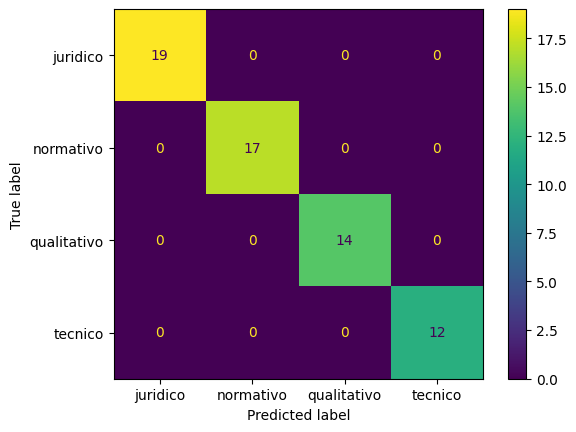

In [256]:
# Avalia o modelo utilizando a mesma lógica apresentada pelo professor:
# realiza a predição dos dados de teste, gera a matriz de confusão
# e calcula as métricas de acurácia, precisão, recall e F1.
#
# Como nosso problema possui 4 classes (AIAA, ESA, FAA e NASA),
# utilizamos a média ponderada ("weighted") nas métricas.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


# Predição
# Utiliza o modelo já treinado para prever as tags
# dos documentos que foram separados para teste.
y_pred = model.predict(X_test_tfidf)


# Matriz de confusão
# Compara as tags reais (y_test) com as tags previstas (y_pred).
# A diagonal principal representa os documentos classificados corretamente.
print('Matriz de Confusão')

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()


# Acurácia
# Calcula a proporção total de documentos classificados corretamente.
acc = accuracy_score(
    y_test,
    y_pred
)

print("Acurácia: {:.2f}".format(acc))


# Precisão média ponderada
# Mede, entre os documentos que o modelo classificou em cada tag,
# quantos realmente pertenciam àquela tag.
#
# O "weighted" calcula a métrica considerando a quantidade
# de documentos existente em cada classe.
prem = precision_score(
    y_true=y_test,
    y_pred=y_pred,
    average="weighted",
    zero_division=0
)

print("Precisão média ponderada: {:.2f}".format(prem))


# Recall médio ponderado
# Mede, entre os documentos que realmente pertenciam a cada tag,
# quantos o modelo conseguiu identificar corretamente.
recm = recall_score(
    y_true=y_test,
    y_pred=y_pred,
    average="weighted",
    zero_division=0
)

print("Recall médio ponderado: {:.2f}".format(recm))


# F1 médio ponderado
# Combina precisão e recall em uma única métrica,
# permitindo avaliar o equilíbrio entre as duas.
f1m = f1_score(
    y_true=y_test,
    y_pred=y_pred,
    average="weighted",
    zero_division=0
)

print("F1 médio ponderado: {:.2f}".format(f1m))

## 15. Análise detalhada das previsões

Nesta etapa, os resultados do conjunto de teste são organizados em uma tabela para comparar, documento por documento, a tag real com a tag prevista pelo modelo. Isso permite identificar com clareza quais arquivos foram classificados corretamente e quais apresentaram erro.

In [257]:
# Cria uma tabela detalhada com o resultado de cada documento do conjunto de teste.
# Essa análise complementa a matriz de confusão, permitindo identificar
# exatamente quais arquivos foram classificados corretamente ou incorretamente.

resultado_teste = pd.DataFrame({

    # Salva o índice original de cada documento utilizado no teste.
    # Esse índice será usado depois para recuperar o nome do arquivo no DataFrame original.
    "texto_indice": X_test.index,

    # Armazena a tag real do documento.
    "tag_real": y_test.values,

    # Armazena a tag prevista pelo modelo.
    "tag_prevista": y_pred
})


# Cria uma nova coluna indicando se a previsão foi correta.
# Retorna True quando a tag prevista é igual à tag real
# e False quando o modelo errou.
resultado_teste["acertou"] = (

    resultado_teste["tag_real"] ==
    resultado_teste["tag_prevista"]

)


# Adiciona o nome do arquivo ao resultado.
# O "texto_indice" corresponde ao índice original do documento no DataFrame df.
resultado_teste = resultado_teste.merge(

    df[["arquivo"]],

    left_on="texto_indice",

    right_index=True
)


# Exibe somente as informações mais importantes
# e ordena os resultados para que os erros apareçam primeiro.
resultado_teste[

    ["arquivo", "tag_real", "tag_prevista", "acertou"]

].sort_values("acertou")

,arquivo,tag_real,tag_prevista,acertou
0,NASA-SP-8117.pdf,normativo,normativo,True
33,NASM20427_ADOPTION_NOTICE.pdf,tecnico,tecnico,True
34,450-SNUG_REV-9.pdf,normativo,normativo,True
35,ECSS-E-HB-50A.pdf,qualitativo,qualitativo,True
36,ECSS-Q-ST-70-09C.pdf,qualitativo,qualitativo,True
...,...,...,...,...
26,NASM24693_ADOPTION_NOTICE.pdf,tecnico,tecnico,True
27,AC23-1419-2D.pdf,juridico,juridico,True
28,ECSS-E-30_7A_APR2000.pdf,qualitativo,qualitativo,True
15,AC_00-2-15.pdf,juridico,juridico,True


## 16. Análise dos termos mais importantes por classe

Nesta etapa, são identificados os termos que tiveram maior influência nas decisões do LinearSVC para cada tag. Essa análise ajuda a entender quais palavras e combinações de palavras o modelo considerou mais relevantes para diferenciar AIAA, ESA, FAA e NASA.

In [258]:
# Obtém todos os termos aprendidos pelo TF-IDF.
# Esses termos representam as palavras e combinações de palavras
# que foram utilizadas como características durante o treinamento.
features = vectorizer.get_feature_names_out()


# Exibe os termos que tiveram maior influência
# na decisão do modelo para cada classe.
print(
    "===== TERMOS MAIS IMPORTANTES POR CLASSE ====="
)


# Percorre cada classe aprendida pelo modelo.
# Exemplo: AIAA, ESA, FAA e NASA.
for i, classe in enumerate(
    model.classes_
):

    # Obtém os pesos calculados pelo LinearSVC
    # para todos os termos da classe atual.
    #
    # Quanto maior o peso positivo de um termo,
    # maior a influência dele para o modelo prever essa classe.
    coeficientes = model.coef_[i]


    # Ordena os pesos e seleciona os 20 maiores.
    #
    # argsort()          -> retorna os índices em ordem crescente
    # [-20:]             -> pega os 20 maiores
    # [::-1]             -> inverte para mostrar do maior para o menor
    maiores_indices = (
        coeficientes
        .argsort()[-20:][::-1]
    )


    # Exibe a classe que está sendo analisada
    print("\n")
    print("=" * 50)
    print("CLASSE:", classe)
    print("=" * 50)


    # Percorre os 20 termos mais importantes da classe
    for indice in maiores_indices:

        # Exibe o termo e o peso atribuído pelo modelo
        print(
            features[indice],
            "->",
            round(
                coeficientes[indice],
                4
            )
        )

===== TERMOS MAIS IMPORTANTES POR CLASSE =====


CLASSE: juridico
faa -> 1.0552
aviation -> 0.7121
ac -> 0.6765
federal -> 0.626
federal aviation -> 0.6144
aviation administration -> 0.5912
aircraft -> 0.4762
advisory circular -> 0.414
circular -> 0.3828
department transportation -> 0.3806
advisory -> 0.3755
service -> 0.3742
ac 20 -> 0.3711
transportation federal -> 0.3636
par -> 0.3461
nas -> 0.3359
airplane -> 0.3249
means -> 0.3189
faa std -> 0.3125
installation -> 0.3103


CLASSE: normativo
nasa -> 0.9687
gsfc -> 0.5847
space flight -> 0.5407
flight center -> 0.503
flight -> 0.4157
program -> 0.4135
space administration -> 0.393
national aeronautics -> 0.392
aeronautics -> 0.3864
goddard -> 0.3733
aeronautics space -> 0.3693
center -> 0.369
version -> 0.3677
correct version -> 0.367
verify correct -> 0.367
goddard space -> 0.3585
vehicle -> 0.3565
mission -> 0.3453
space -> 0.3442
effective date -> 0.3394


CLASSE: qualitativo
ecss -> 0.9288
esa -> 0.6437
european -> 0.5458
issue 

## 17. Modelo treinado e possibilidade de expansão

Neste ponto, o modelo já está treinado para classificar documentos entre as tags AIAA, ESA, FAA e NASA, utilizando os textos processados pelo TF-IDF e o classificador LinearSVC.

Caso seja necessário adicionar novas tags futuramente, não é necessário alterar a lógica principal do treinamento. Basta adicionar os documentos da nova categoria em uma pasta com o nome da nova tag, seguindo a mesma estrutura utilizada atualmente.

Por exemplo:
```text
DOCS_API/
├── AIAA/
├── ESA/
├── FAA/
├── NASA/
└── FAR/
```

Ao executar novamente o processamento, o DataFrame identificará automaticamente a nova tag pelo nome da pasta

## 18. Função para classificação de novos documentos

Nesta etapa, é criada uma função responsável por receber um novo arquivo PDF e classificá-lo utilizando o modelo já treinado. O documento passa pelo mesmo fluxo utilizado durante o treinamento: extração do texto, limpeza, transformação com o TF-IDF já ajustado e, por fim, predição da tag pelo LinearSVC.

In [262]:
def prever_tag_pdf(
    caminho_pdf,
    vectorizer,
    modelo,
    limite_confianca=0.3,
    top_n=5
):

    # Extrai o texto
    texto = extrair_texto_pdf(caminho_pdf)

    print(
        "Quantidade de caracteres extraídos:",
        len(texto.strip())
    )

    # Caso 1: nenhum texto foi extraído
    if len(texto.strip()) == 0:

        print(
            "NÃO CLASSIFICADO:",
            "nenhum texto foi extraído."
        )

        return {
            "etiqueta_classificada": "NÃO CLASSIFICADO"
        }

    # Limpa o texto
    texto_limpo = limpar_texto(texto)

    print(
        "Quantidade de caracteres após limpeza:",
        len(texto_limpo)
    )

    # Caso 2: pouco conteúdo útil após limpeza
    if len(texto_limpo) < 100:

        print(
            "NÃO CLASSIFICADO:",
            "não foi possível obter conteúdo textual suficiente."
        )

        return {
            "etiqueta_classificada": "NÃO CLASSIFICADO"
        }

    # Transforma utilizando o TF-IDF treinado
    texto_tfidf = vectorizer.transform(
        [texto_limpo]
    )

    # Caso 3: nenhum termo reconhecido pelo TF-IDF
    if texto_tfidf.nnz == 0:

        print(
            "NÃO CLASSIFICADO:",
            "nenhum termo reconhecido pelo TF-IDF."
        )

        return {
            "etiqueta_classificada": "NÃO CLASSIFICADO"
        }

    # Obtém os scores das classes
    scores = modelo.decision_function(
        texto_tfidf
    )[0]

    print("\nScores por classe:")

    for classe, score in zip(
        modelo.classes_,
        scores
    ):
        print(
            classe,
            "->",
            round(score, 4)
        )

    # Identifica a classe com maior score
    indice_classe = scores.argmax()

    maior_score = scores[indice_classe]

    classe_candidata = modelo.classes_[
        indice_classe
    ]

    print(
        "\nMelhor classificação:",
        classe_candidata
    )

    print(
        "Maior score:",
        round(maior_score, 4)
    )

    print(
        "Limite mínimo:",
        limite_confianca
    )

    # Verifica o limite mínimo
    if maior_score < limite_confianca:

        print(
            "\nNÃO CLASSIFICADO:",
            "score abaixo do limite."
        )

        return {
            "etiqueta_classificada": "NÃO CLASSIFICADO"
        }

    print(
        "\nCLASSIFICADO:",
        classe_candidata
    )

    return {
        "etiqueta_classificada": classe_candidata
    }

## 19. Teste de classificação com novo documento

Nesta etapa, um novo arquivo PDF é enviado pelo Google Colab e processado pela função criada anteriormente. O documento é validado, transformado com o mesmo TF-IDF utilizado no treinamento e classificado pelo modelo, exibindo ao final a tag prevista.

In [264]:
from google.colab import files
import json

novo_upload = files.upload()

for nome_arquivo in novo_upload.keys():

    if nome_arquivo.lower().endswith(".pdf"):

        resultado = prever_tag_pdf(
            nome_arquivo,
            vectorizer,
            model
        )

        print(
            json.dumps(
                resultado,
                ensure_ascii=False,
                indent=2
            )
        )

Saving NASM90726_ADOPTION_NOTICE.pdf to NASM90726_ADOPTION_NOTICE (1).pdf

Resumo da extração:
Páginas lidas normalmente: 1
Páginas processadas com OCR: 0
Caracteres úteis encontrados: 704
Quantidade de caracteres extraídos: 842
Quantidade de caracteres após limpeza: 704

Scores por classe:
juridico -> -0.9718
normativo -> -0.9848
qualitativo -> -0.9994
tecnico -> 0.9551

Melhor classificação: tecnico
Maior score: 0.9551
Limite mínimo: 0.3

CLASSIFICADO: tecnico
{
  "etiqueta_classificada": "tecnico"
}


20. Exportação do modelo treinado

Nesta etapa, o TF-IDF e o modelo LinearSVC já treinados são armazenados em um único arquivo. Esse arquivo poderá ser carregado posteriormente pelo backend em Python/Django REST para realizar a classificação de novos documentos sem a necessidade de executar novamente o treinamento.

In [265]:
# Importa o Joblib, utilizado para salvar objetos Python treinados
import joblib


# Agrupa o TF-IDF e o modelo treinado em um único objeto.
# É necessário salvar os dois porque:
#
# vectorizer -> transforma novos textos em valores numéricos
# model      -> utiliza esses valores para prever a tag
artefato_modelo = {
    "vectorizer": vectorizer,
    "model": model
}


# Define o nome do arquivo que armazenará o treinamento
caminho_modelo = "/content/modelo_categorizacao_tags.joblib"


# Salva o TF-IDF e o modelo treinado
joblib.dump(
    artefato_modelo,
    caminho_modelo
)


print(
    "Modelo exportado com sucesso:",
    caminho_modelo
)

Modelo exportado com sucesso: /content/modelo_categorizacao_tags.joblib


## 21. Download do modelo treinado

Nesta etapa, o arquivo contendo o TF-IDF e o modelo LinearSVC treinado é baixado do Google Colab para que possa ser utilizado posteriormente pelo backend da aplicação.

In [266]:
# Importa a ferramenta de download do Google Colab
from google.colab import files

# Faz o download do arquivo contendo o modelo treinado
files.download(
    "/content/modelo_categorizacao_tags.joblib"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Resultado final da PoC

Esta prova de conceito demonstrou, de forma reproduzível, o processo de preparação, treinamento, avaliação, utilização e exportação de um modelo de Machine Learning capaz de atribuir automaticamente uma tag a documentos PDF.

O dataset utilizado nesta versão possui **200 documentos**, distribuídos igualmente entre as tags **AIAA, ESA, FAA e NASA**, com **50 documentos por categoria**. Durante a validação inicial, não foram encontrados valores nulos e todos os 200 documentos tiveram conteúdo textual extraído com sucesso.

### Fluxo desenvolvido

O processo implementado na PoC segue o seguinte fluxo:

~~~text
Documentos PDF
      ↓
Extração do texto
      ↓
Limpeza e padronização
      ↓
Separação entre treino e teste
      ↓
TF-IDF
      ↓
LinearSVC
      ↓
Avaliação
      ↓
Classificação de novos documentos
~~~

Os documentos são fornecidos em um arquivo ZIP organizado em pastas, sendo o nome de cada pasta utilizado como a tag correta do documento.

~~~text
DOCS_API/
├── AIAA/
├── ESA/
├── FAA/
└── NASA/
~~~

A estrutura de pastas é percorrida automaticamente e os arquivos são organizados em um DataFrame contendo o nome do documento, seu caminho e sua respectiva tag.

O conteúdo textual dos PDFs é extraído utilizando o **PyMuPDF**. Nesta PoC, a leitura foi limitada às primeiras **30 páginas de cada documento**, buscando reduzir o custo de processamento e padronizar a quantidade de conteúdo analisada entre documentos de tamanhos diferentes.

Após a extração, os textos passam por uma etapa de limpeza e padronização, na qual são convertidos para letras minúsculas e são removidos caracteres especiais, quebras de linha, tabulações e espaços duplicados.

Também foi realizada uma análise de **marcadores das organizações**, apenas para compreender melhor o dataset e verificar a presença de termos que podem contribuir para a identificação das tags. Essa análise não participa diretamente do treinamento.

Os marcadores relacionados às próprias organizações foram encontrados em:

- **AIAA:** 50 de 50 documentos;
- **ESA:** 49 de 50 documentos;
- **FAA:** 45 de 50 documentos;
- **NASA:** 50 de 50 documentos.

### Treinamento

Para o treinamento, o texto limpo de cada documento é utilizado como entrada (`X`) e sua respectiva tag como saída esperada (`y`).

Os dados são separados utilizando `train_test_split`, com:

- **65% dos documentos destinados ao treinamento**;
- **35% dos documentos destinados ao teste**;
- `random_state=1`, garantindo a reprodução da mesma divisão;
- `stratify=y`, mantendo a proporção das quatro classes entre treinamento e teste.

Como o modelo não trabalha diretamente com texto, os documentos são convertidos em representações numéricas utilizando o **TF-IDF (`TfidfVectorizer`)**.

O TF-IDF foi configurado para:

- remover stopwords da língua inglesa;
- ignorar termos presentes em apenas um documento;
- ignorar termos presentes em mais de 95% dos documentos;
- limitar o vocabulário a no máximo 30.000 características;
- considerar palavras isoladas e combinações de duas palavras (`ngram_range=(1, 2)`);
- reduzir o impacto de termos excessivamente repetidos utilizando `sublinear_tf`.

O vocabulário do TF-IDF é aprendido **somente com os dados de treinamento**, utilizando `fit_transform()`. Para os dados de teste é utilizado apenas `transform()`, evitando que informações utilizadas para avaliação participem do aprendizado.

Após a vetorização, os dados são utilizados para treinar o classificador **LinearSVC**, responsável por aprender padrões capazes de diferenciar as tags AIAA, ESA, FAA e NASA.

### Resultados obtidos

Após o treinamento, o modelo é aplicado aos documentos separados para teste e as previsões são comparadas com suas respectivas tags reais.

A avaliação é realizada utilizando:

- matriz de confusão;
- acurácia;
- precisão média ponderada;
- recall médio ponderado;
- F1 médio ponderado.

Na execução realizada nesta PoC, foram obtidos os seguintes resultados:

~~~text
Acurácia:                 0.99
Precisão média ponderada: 0.99
Recall médio ponderado:   0.99
F1 médio ponderado:       0.99
~~~

Os resultados indicam que, para o conjunto de documentos utilizado nesta prova de conceito, o modelo conseguiu diferenciar as quatro categorias com alto nível de acerto.

Além das métricas gerais, foi criada uma análise individual das previsões, permitindo visualizar:

- nome do arquivo;
- tag real;
- tag prevista;
- indicação de acerto ou erro.

Dessa forma, é possível identificar exatamente quais documentos foram classificados incorretamente e analisar posteriormente o motivo do erro.

Também foram analisados os termos que receberam maior peso pelo `LinearSVC` em cada classe. Alguns dos termos identificados foram:

~~~text
AIAA → dod, adopting activity, dla, aerospace
ESA  → ecss, european, esa, european space
FAA  → faa, aircraft, aviation, advisory circular
NASA → gsfc, nasa, nasa gov, goddard
~~~

Essa análise auxilia na interpretação do modelo, permitindo observar quais características textuais tiveram maior influência na classificação de cada categoria.

### Classificação de novos documentos

Após o treinamento, a PoC também demonstra a utilização do modelo para classificar documentos que não fazem parte do conjunto utilizado no treinamento.

O fluxo para um novo documento é:

~~~text
Novo PDF
   ↓
Extração do texto
   ↓
Limpeza e padronização
   ↓
vectorizer.transform()
   ↓
model.predict()
   ↓
Tag prevista
~~~

O novo documento utiliza exatamente o mesmo processo de extração e limpeza aplicado durante o treinamento.

O `TfidfVectorizer` não é treinado novamente. É utilizado apenas `transform()`, garantindo que o novo documento seja representado utilizando o mesmo vocabulário aprendido anteriormente.

Em seguida, o vetor gerado é enviado ao `LinearSVC`, que retorna uma das tags conhecidas pelo modelo:

~~~text
AIAA / ESA / FAA / NASA
~~~

Durante a execução da PoC, também foi realizado um teste com um novo documento, obtendo o seguinte resultado:

~~~text
Documento: NASM122076_THRU_122115_ADOPTION_NOTICE.pdf
Tag prevista: AIAA
~~~

Dessa forma, a PoC demonstra não apenas o treinamento e a avaliação do modelo, mas também sua utilização prática para documentos externos.

### Persistência do modelo

Para permitir que o treinamento seja reutilizado posteriormente, o `TfidfVectorizer` e o `LinearSVC` são armazenados juntos utilizando a biblioteca `joblib`.

O arquivo gerado é:

`modelo_categorizacao_tags.joblib`

Sua estrutura lógica é:

~~~text
modelo_categorizacao_tags.joblib
│
├── vectorizer
│   └── TF-IDF e vocabulário aprendido
│
└── model
    └── LinearSVC treinado
~~~

Dessa forma, não é necessário executar todo o processo de treinamento sempre que um novo documento precisar ser classificado.

### Integração com o backend

O arquivo `modelo_categorizacao_tags.joblib` poderá ser integrado posteriormente ao backend desenvolvido em **Python/Django REST**.

O fluxo esperado na aplicação será:

~~~text
Documento recebido pela API
        ↓
Extração do texto
        ↓
Limpeza e padronização
        ↓
Carregamento do arquivo .joblib
        ↓
vectorizer.transform()
        ↓
model.predict()
        ↓
Tag prevista
        ↓
Atribuição da tag ao documento
~~~

O backend não deverá executar `fit()` ou `fit_transform()` durante a classificação.

O treinamento já foi realizado anteriormente. Para realizar uma nova previsão, o backend deverá apenas carregar o `vectorizer` e o `model`, transformar o texto recebido e executar `predict()`.

Dessa forma:

- **Google Colab:** responsável pela preparação dos dados, treinamento, avaliação e geração do modelo;
- **Backend Django REST:** responsável por carregar e utilizar o modelo treinado para classificar novos documentos.

### Inclusão de novas tags

A estrutura desenvolvida permite a inclusão de novas categorias futuramente.

Para adicionar uma nova tag, basta criar uma nova pasta dentro do dataset e adicionar documentos previamente classificados naquela categoria.

Exemplo:

~~~text
DOCS_API/
├── AIAA/
├── ESA/
├── FAA/
├── NASA/
└── NOVA_TAG/
~~~

Como o nome da pasta é utilizado automaticamente como tag, a nova categoria será incorporada ao dataset durante o processamento.

Após adicionar os documentos da nova categoria, será necessário:

1. executar novamente a preparação do dataset;
2. executar novamente o TF-IDF;
3. treinar novamente o `LinearSVC`;
4. avaliar o novo modelo;
5. gerar uma nova versão do arquivo `.joblib`.

A lógica principal do treinamento não precisa ser alterada. É necessário apenas fornecer uma quantidade adequada de documentos representativos da nova categoria e realizar novamente o treinamento.

### Conclusão

A prova de conceito demonstrou que a abordagem utilizando **TF-IDF + LinearSVC** é capaz de realizar a categorização automática dos documentos utilizados neste experimento.

O processo desenvolvido permite:

- preparar automaticamente o dataset;
- extrair o conteúdo textual dos PDFs;
- validar os documentos processados;
- limpar e padronizar os textos;
- transformar os textos em representações numéricas utilizando TF-IDF;
- treinar um classificador LinearSVC;
- avaliar o desempenho por meio de métricas e matriz de confusão;
- analisar individualmente as previsões;
- identificar os termos mais relevantes para cada classe;
- classificar novos documentos;
- exportar o treinamento para utilização posterior pela aplicação.

Com os **200 documentos utilizados nesta versão**, o modelo apresentou aproximadamente **99% de desempenho nas métricas avaliadas no conjunto de teste**.

Como resultado final, o treinamento pode ser persistido no arquivo `modelo_categorizacao_tags.joblib`, permitindo que o mesmo TF-IDF e o mesmo classificador sejam posteriormente carregados pelo backend em Python/Django REST para realizar novas classificações sem a necessidade de retreinamento a cada requisição.